Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', None)

### Изучение общей информации о данных

Прочитаем файл с данными и изучим общую информацию о данных

In [2]:
dt = pd.read_csv('./notebooks/data/data_final.csv')
display(dt.info())
display(dt.head())

<class 'pandas.DataFrame'>
RangeIndex: 134393 entries, 0 to 134392
Data columns (total 67 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   first_seen                134393 non-null  str    
 1   days_on_market            134393 non-null  int64  
 2   event_closed              134393 non-null  int64  
 3   mortgage_allowed          134393 non-null  int64  
 4   deal_conditions           134393 non-null  str    
 5   region                    134393 non-null  str    
 6   municipality              134393 non-null  str    
 7   district                  134393 non-null  str    
 8   lat                       134393 non-null  float64
 9   lon                       134393 non-null  float64
 10  n_metro                   134393 non-null  int64  
 11  nearest_metro             134393 non-null  str    
 12  nearest_metro_time        134393 non-null  float64
 13  nearest_metro_walk        134393 non-null  int64  
 14 

None

,first_seen,days_on_market,event_closed,mortgage_allowed,deal_conditions,region,municipality,district,lat,lon,n_metro,nearest_metro,nearest_metro_time,nearest_metro_walk,rooms,is_studio,flat_type,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,renovation,window_view,is_apartments,building_type,parking,is_new_building,seller_type,seller_user_type,phone_protected,seller_is_owner,status,cian_user_id,is_penthouse,room_type,demolished_in_renovation,views_total,price_first,price_last,price_points,dist_to_center,price_per_m2,building_age,is_ready,completion_year,years_to_completion,is_presale,has_completion,had_discount,price_drop_pct,price_range_pct,is_first_floor,is_last_floor,floor_ratio,living_to_total,kitchen_to_total,area_per_room,ppm2_to_district,ppm2_to_municipality,total_lifts,has_lift,bath_separate,bath_combined,balcony_count,loggia_count
0,2026-04-06 00:00:00+00:00,774,1,1,alternative,Москва,unknown,Новогиреево,55.755905,37.820045,3,Новогиреево,7.0,1,1,0,rooms,41.6,21.8,10.7,15,22,2.7,euro,unknown,0,monolith,ground,0,agency,unknown,1,0,NaN,NaN,0,unknown,0,2735.0,16999999,16999999,7,12.681626,408653.822115,3,1,NaN,NaN,0,0,0,0.000000,0.000000,0,0,0.681818,0.524038,0.257212,41.60,1.061066,0.938880,5,1,0,1,0,1
1,2024-03-05 00:00:00+00:00,763,1,1,free,Москва,unknown,Бабушкинский,55.877790,37.677570,3,Бабушкинская,22.0,1,1,0,rooms,41.0,23.0,11.0,4,19,2.7,cosmetic,unknown,0,panel,underground,0,agency,unknown,1,0,NaN,NaN,0,unknown,0,779.0,14300000,16150000,6,14.481951,393902.439024,3,1,NaN,NaN,0,0,0,-0.129371,0.165035,0,0,0.210526,0.560976,0.268293,41.00,0.968921,0.904989,2,1,0,1,1,0
2,2024-08-28 00:00:00+00:00,798,1,1,free,Московская область,Королев,unknown,55.905420,37.866370,3,Медведково,26.0,0,2,0,rooms,60.1,30.0,15.0,2,14,2.8,design,unknown,0,monolith,underground,0,agency,unknown,1,0,NaN,NaN,0,unknown,0,1248.0,12800000,13500000,8,23.078438,224625.623960,6,1,NaN,NaN,0,0,0,-0.054688,0.054688,0,0,0.142857,0.499168,0.249584,30.05,0.997712,1.172621,6,1,0,1,1,0
3,2024-03-05 00:00:00+00:00,766,1,1,free,Москва,unknown,Ярославский,55.841892,37.666880,3,Ростокино,5.0,1,2,0,rooms,41.0,30.8,5.2,4,35,3.1,unknown,yard,1,monolith,underground,0,agency,unknown,1,0,NaN,NaN,0,unknown,0,2714.0,11705500,13919500,25,10.461232,339500.000000,6,1,2026.0,0.0,0,1,0,-0.189142,0.189142,0,0,0.114286,0.751220,0.126829,20.50,0.984851,0.816215,30,1,0,1,-1,-1
4,2025-05-27 00:00:00+00:00,772,1,1,free,Москва,Троицк,unknown,55.453564,37.284280,3,Потапово,24.0,0,2,0,rooms,67.3,34.3,15.0,2,5,3.0,unknown,unknown,0,monolithBrick,ground,0,specialist,unknown,1,0,NaN,NaN,0,unknown,0,2118.0,10000000,10500000,9,39.234567,156017.830609,1,1,NaN,NaN,0,0,0,-0.050000,0.200000,0,0,0.400000,0.509658,0.222883,33.65,0.692979,0.902925,2,1,1,1,0,2


Видим, что не у всех данных корректный тип данных, поэтому приведем столбцы датафрейма к корректным типам. first_seen нужно сделать датой, количественные показатели числом, а бинарные сделать типом bool.

In [3]:
dt['first_seen'] = pd.to_datetime(dt['first_seen'],format='ISO8601')
dt[['rooms','total_lifts','views_total']] = dt[['rooms','total_lifts','views_total']].astype('Int64')
dt[['event_closed','mortgage_allowed','nearest_metro_walk','is_studio','is_apartments','is_new_building',
    'phone_protected','had_discount','is_first_floor','is_last_floor','has_lift',
    'demolished_in_renovation','is_penthouse','seller_is_owner']] = dt[['event_closed','mortgage_allowed',
                                                                                         'nearest_metro_walk','is_studio','is_apartments','is_new_building',
                                                                                         'phone_protected','had_discount','is_first_floor','is_last_floor','has_lift',
                                                                                         'demolished_in_renovation','is_penthouse','seller_is_owner']].astype('bool')

Посмотрим на данные еще раз, чтобы убедиться, что типы данных теперь корректные и соответствуют по смыслу.

In [4]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 134393 entries, 0 to 134392
Data columns (total 67 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   first_seen                134393 non-null  datetime64[us, UTC]
 1   days_on_market            134393 non-null  int64              
 2   event_closed              134393 non-null  bool               
 3   mortgage_allowed          134393 non-null  bool               
 4   deal_conditions           134393 non-null  str                
 5   region                    134393 non-null  str                
 6   municipality              134393 non-null  str                
 7   district                  134393 non-null  str                
 8   lat                       134393 non-null  float64            
 9   lon                       134393 non-null  float64            
 10  n_metro                   134393 non-null  int64              
 11  nearest_met

Посмотрим на количество пропусков

In [5]:
dt.isna().sum().sort_values(ascending = False)

status                 110177
cian_user_id           110177
completion_year         62996
years_to_completion     62996
views_total              3858
                        ...  
has_lift                    0
bath_separate               0
bath_combined               0
balcony_count               0
loggia_count                0
Length: 67, dtype: int64

Видим, что пропусков нет нигде, кроме трех полей: в views_today, photos_count и views_total.

In [6]:
(dt == 'unknown').sum().sort_values(ascending = False)

room_type           127451
seller_user_type    126686
district             71111
window_view          64408
renovation           61464
                     ...  
has_lift                 0
bath_separate            0
bath_combined            0
balcony_count            0
loggia_count             0
Length: 67, dtype: Int64

Посмотрим, сколько unknown есть в данных, их значительно больше, чем пропусков, нас особенно беспокоит 95% по district

In [7]:
dt.describe()

,days_on_market,lat,lon,n_metro,nearest_metro_time,rooms,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,cian_user_id,views_total,price_first,price_last,price_points,dist_to_center,price_per_m2,building_age,is_ready,completion_year,years_to_completion,is_presale,has_completion,price_drop_pct,price_range_pct,floor_ratio,living_to_total,kitchen_to_total,area_per_room,ppm2_to_district,ppm2_to_municipality,total_lifts,bath_separate,bath_combined,balcony_count,loggia_count
count,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.0,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,2.421600e+04,130535.0,1.343930e+05,1.343930e+05,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,71397.000000,71397.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.000000,134393.0,134393.000000,134393.000000,134393.000000,134393.000000
mean,77.260356,55.727316,37.575322,3.069200,13.339281,1.875388,54.833843,28.435981,12.726995,10.413452,19.480896,2.834535,8.762234e+07,572.17796,1.960549e+07,1.966028e+07,10.451318,20.461398,354946.865134,16.215413,0.918433,2026.323851,0.323851,0.297047,0.531255,-0.005699,0.042448,0.551874,0.508887,0.245613,31.172651,1.047242,1.044874,3.879413,0.010752,0.332369,-0.395229,-0.368695
std,99.729483,0.166526,0.256157,1.051414,6.167687,0.888302,19.296515,12.915134,5.137702,8.711473,12.056206,0.257908,5.155112e+07,1209.917475,1.288826e+07,1.287253e+07,7.279397,13.999150,163056.615494,20.568748,0.273705,2.489487,2.489487,0.456959,0.499024,0.073552,0.076392,0.286522,0.114886,0.098207,7.897613,0.308606,0.288042,4.177866,0.789677,0.996667,0.844030,0.877850
min,2.000000,54.470955,35.501183,0.000000,1.000000,0.0,23.200000,9.200000,4.000000,-2.000000,1.000000,2.000000,1.740000e+02,1.0,4.841000e+06,4.300000e+06,1.000000,0.429728,101000.000000,-3.000000,0.000000,2000.000000,-26.000000,0.000000,0.000000,-5.000000,0.000000,-0.666667,0.095951,0.042373,0.722222,0.153737,0.179648,0.0,-1.000000,-1.000000,-1.000000,-1.000000
25%,21.000000,55.627098,37.431100,3.000000,8.000000,1.0,39.000000,18.000000,9.000000,4.000000,12.000000,2.700000,4.009310e+07,21.0,1.087430e+07,1.090000e+07,6.000000,11.610643,227430.188218,3.000000,1.000000,2026.000000,0.000000,0.000000,0.000000,-0.002093,0.000000,0.300000,0.428870,0.169355,25.266667,0.847690,0.861050,2.0,-1.000000,-1.000000,-1.000000,-1.000000
50%,41.000000,55.719315,37.547604,3.000000,13.000000,2.0,51.400000,27.000000,12.000000,8.000000,17.000000,2.800000,1.093352e+08,156.0,1.634792e+07,1.645218e+07,8.000000,19.122097,328247.990196,6.000000,1.000000,2027.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.555556,0.514190,0.227723,30.300000,1.000185,1.000000,3.0,0.000000,1.000000,-1.000000,-1.000000
75%,94.000000,55.830640,37.734756,3.000000,18.000000,2.0,65.800000,36.200000,16.000000,14.000000,24.000000,2.970000,1.346401e+08,641.0,2.380000e+07,2.389939e+07,14.000000,25.209870,442857.142857,23.000000,1.000000,2028.000000,2.000000,1.000000,1.000000,0.000000,0.051897,0.800000,0.591900,0.307692,36.500000,1.186589,1.177125,5.0,1.000000,1.000000,0.000000,0.000000
max,798.000000,56.762768,39.850730,15.000000,60.000000,36.0,138.400000,73.500000,32.100000,76.000000,97.000000,7.800000,1.423617e+08,62983.0,1.100000e+08,1.228901e+08,154.000000,158.695097,987900.000000,206.000000,1.000000,2031.000000,5.000000,1.000000,1.000000,0.900000,0.406065,1.000000,1.000000,1.000000,135.900000,4.429701,4.549636,55.0,9.000000,11.000000,4.000000,4.000000


Посмотрели какие аномалии есть в данных. Нас особенно смущает, что 
- rooms = 0 (min), так как не бывает квартир, где нет комнат
- floor = -2 (min) - отрицательное значение этажа
- ceiling_height = 0 (min), 3250 (max) - не бывает потолков, где высота 0
- views_total = 536340 (max) - здесь нас смутило слишком большое кол-во просмотров
- dist_to_center = 2811.959345 (max) - подозрительно большое расстояние для городской недвижимости
- building_age = -3 (min), 934 (max), нереалистичный возраст здания
- floor_ratio = -0.4 (min), не имеет смысла отрицательное значение
- total_lifts = 43 (max) - так не бывает 

Посмотрим какие уникальные значения есть в каждом столбце, чтобы определить что нужно поправить, отфильтровать

In [8]:
for col in dt.select_dtypes(include = 'object').columns:
    print()
    print(col, dt[col].nunique())
    print(dt[col].value_counts().head(10))

# investment,dzhsk,свободная продажа -> alternative
# отфильтровать регионы - Москва и МО
# проверить district
# привести bathrooms?
# привести balcony?
# window_view -> на сколько сторон окна: yardAndStreet = 2, yard = 1, street = 1
# привести building_type


deal_conditions 8
deal_conditions
free                 64139
fz214                57899
alternative           9223
dupt                  2761
pdkp                   323
investment              36
dzhsk                   10
свободная продажа        2
Name: count, dtype: int64

region 2
region
Москва                80850
Московская область    53543
Name: count, dtype: int64

municipality 179
municipality
unknown                        42840
НАО (Новомосковский)            8394
Ленинский городской округ       5580
ЮВАО                            4656
Мытищи                          4592
Балашиха                        3783
САО                             3637
Красногорск городской округ     3539
ЮАО                             3174
Химки                           3150
Name: count, dtype: int64

district 163
district
unknown                 71111
Даниловский              2898
Можайский                2711
Раменки                  2215
Печатники                2136
Очаково-Матвеевское     

C:\Users\Nikita\AppData\Local\Temp\ipykernel_11300\2946004304.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in dt.select_dtypes(include = 'object').columns:


Посмотрим сколько дней объявление было показано

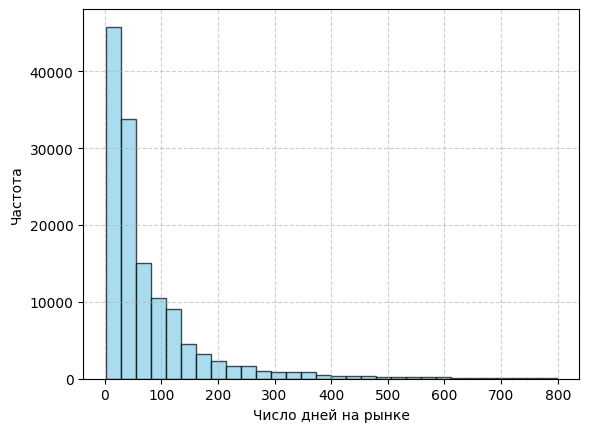

In [9]:
plt.hist(dt['days_on_market'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.xlabel('Число дней на рынке')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

На графике видим, что большинство квартир были на рынке небольшое количество дней и быстро продавались.

In [10]:
dt = dt[dt['region'].isin(['Москва','Московская область'])]
dt.loc[dt['views_total']>100000, 'views_total'] = np.nan
dt = dt[dt['ceiling_height'].between(2, 8)]
dt = dt[dt['building_age']<300]
dt['price_range_pct'] = dt['price_range_pct'].clip(upper=dt['price_range_pct'].quantile(0.99))
dom_low, dom_high = dt['days_on_market'].quantile([0.01, 0.99])
dt = dt[dt['days_on_market'].between(dom_low, dom_high)]

Очистим данные, удалим ненужные и отфильтруем аномальные значения.
- удалим views_today и photos_count - счетные признаки, более 80% пропусков, малая содержательная нагрузка + views_total
- отфильтруем только объявления в Москве и МО. Это должно также убрать выбросы по dist_to_center, lat, lon
- что касается rooms = 0 (min) - вероятно, свободная планировка, оставим пока. floor = -2 (min) - сомнительно, но окэй :)
- views_total = 536340 - такой выброс всего один, следующее максимальное значение 58733, скорее всего ошибка. Присвоим ему NaN.
- ceiling_height - возьмем от 2 метров до 8 метров (пентхаус), остальные скорее всего ошибка
- building_age = -3 (min), 934 (max) - верхнее значение точно ошибка, это Подольск, ему еще нет столько лет. А нижние (отрицательные) значения - если это в строящихся домах, то почему маркер is_ready у всех true? Надо разобраться.
- days_on_market - срезаем хвосты по 1 и 99 перцентилю (снизу мгновенные репосты, сверху "продается 10+ лет")

Посмотрим зависимости для цены за кв.м. и переменных с наибольшей корреляцией, а также зависимости для срока продажи и переменных с наибольшей корреляцией

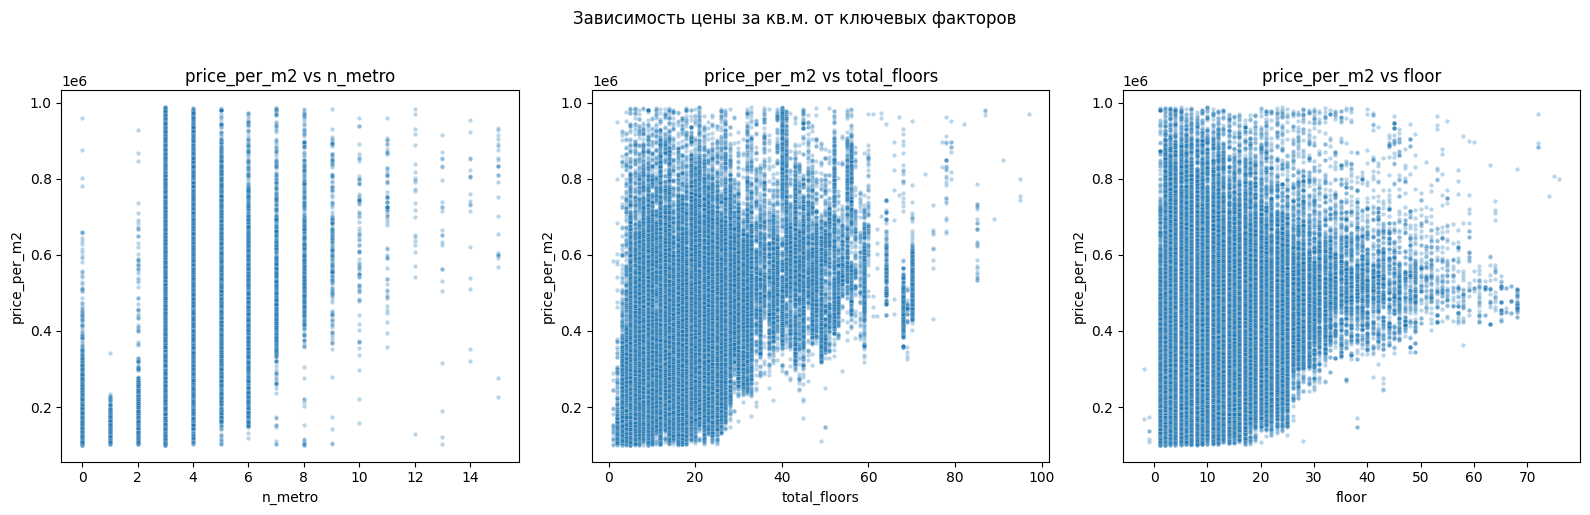

In [11]:
pairs = [
    ('n_metro', 'price_per_m2'),
    ('total_floors', 'price_per_m2'),
    ('floor', 'price_per_m2')
]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(data=dt, x=x_col, y=y_col, alpha=0.3, s=10, ax=ax)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs {x_col}')

plt.suptitle('Зависимость цены за кв.м. от ключевых факторов', y=1.02)
plt.tight_layout()
plt.show()

Видим, что цена за квадратный метр растёт с увеличением числа станций метро рядом и снижается в многоэтажных домах. Наиболее дорогие квартиры расположены на средних и низких этажах.



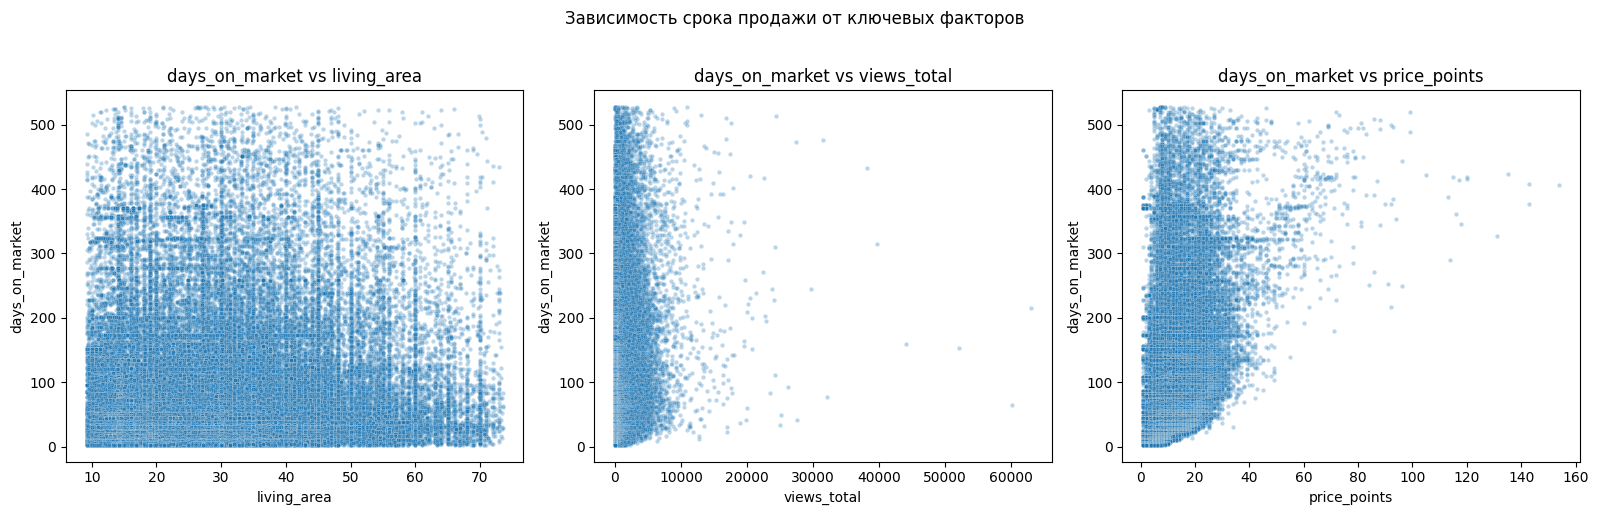

In [12]:
pairs = [
    ('living_area', 'days_on_market'),
    ('views_total', 'days_on_market'),
    ('price_points', 'days_on_market')
]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(data=dt, x=x_col, y=y_col, alpha=0.3, s=10, ax=ax)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs {x_col}')

plt.suptitle('Зависимость срока продажи от ключевых факторов', y=1.02)
plt.tight_layout()
plt.show()

Посмотрим на распределение цен за кв. метр

Срок продажи увеличивается для квартир с большой жилой площадью и низкой ценой за квадратный метр. А также видим, что чем больше просмотров, тем быстрее продается квартира.



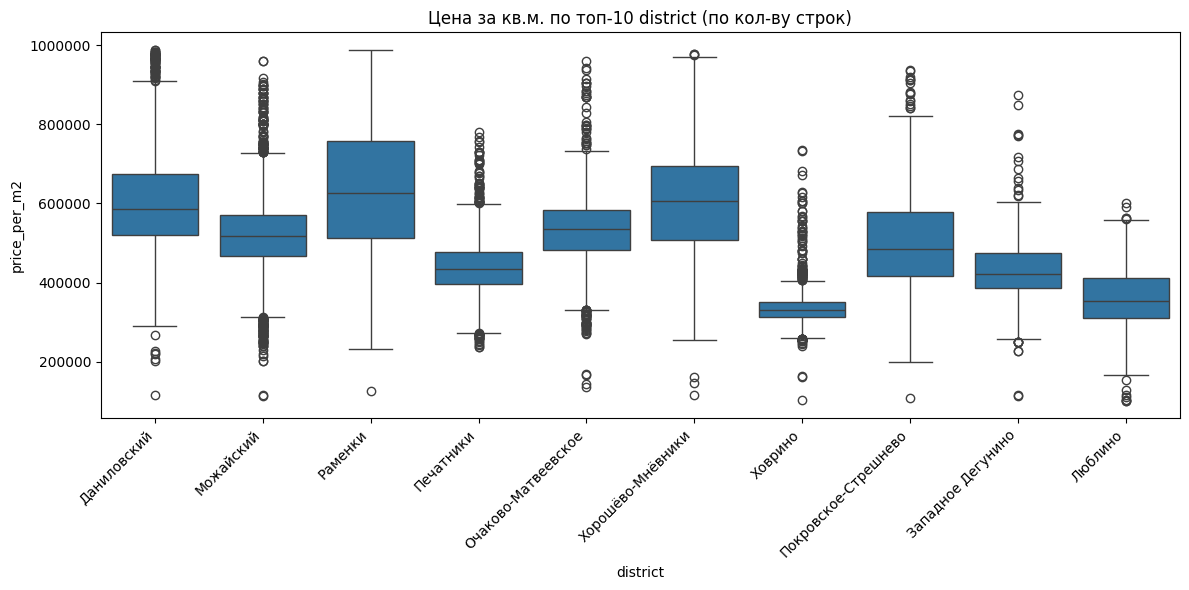

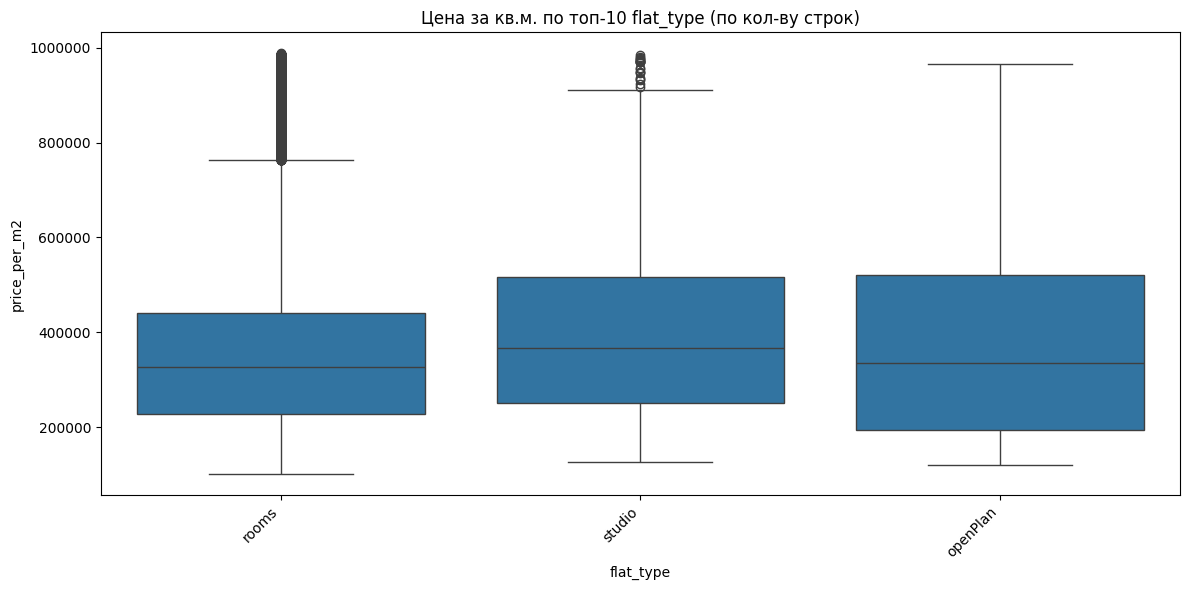

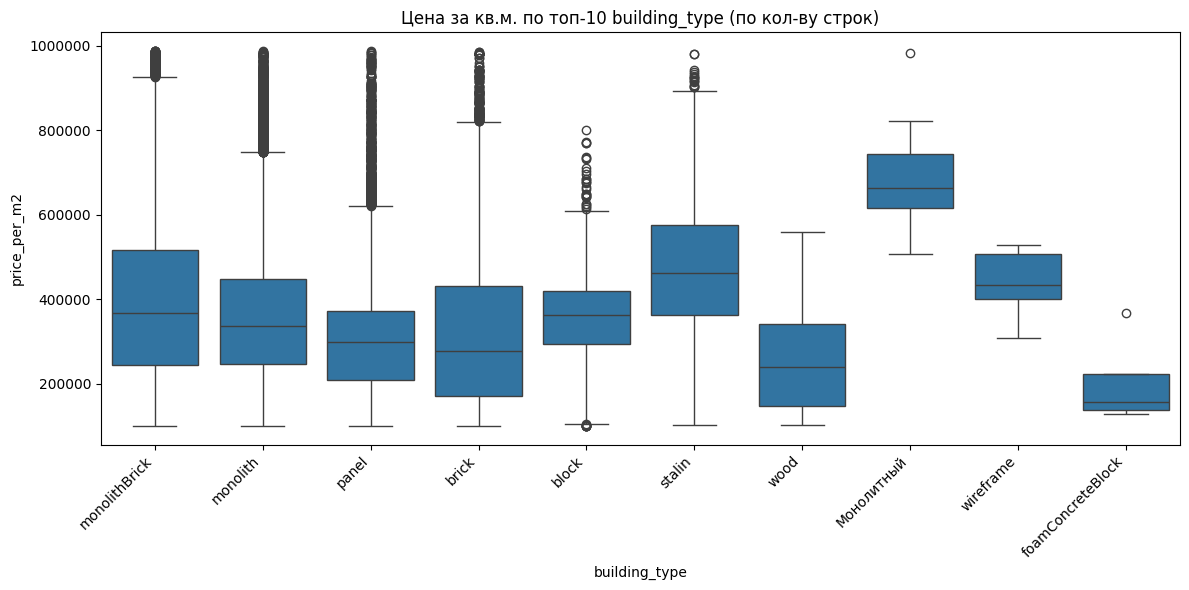

In [13]:
cols_to_plot = ['district', 'flat_type', 'building_type']

for col in cols_to_plot:
    dt_clean = dt[dt[col].ne('unknown') & dt[col].notna()]
    top_cats = dt_clean[col].value_counts().head(10).index
    dt_top = dt_clean[dt_clean[col].isin(top_cats)]
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=dt_top, x=col, y='price_per_m2', order=top_cats)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Цена за кв.м. по топ-10 {col} (по кол-ву строк)')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()


Видим, что самые высокие средние цены за кв. метр в районах Раменки и Пресненский, а также в студиях и домах сталинской постройки.

### Распределение таргета (days_on_market) по категориальным признакам

In [14]:
def target_by_category(frame, col, target='days_on_market', min_count=200):
    g = frame.groupby(col)[target]
    table = g.agg(
        n='count',
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        p50='median',
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    return table[table['n'] >= min_count].sort_values('p50').round(1)

cat_features = ['region', 'seller_type', 'seller_user_type', 'room_type', 'rooms', 'is_new_building', 'is_apartments',
                'deal_conditions', 'building_type', 'renovation', 'parking', 'flat_type',
                'has_lift', 'mortgage_allowed', 'nearest_metro_walk',
                'demolished_in_renovation', 'is_penthouse', 'seller_is_owner']

for col in cat_features:
    print(col)
    display(target_by_category(dt, col))

region


,n,p10,p25,p50,p75,p90
region,,,,,,
Москва,79664,9.0,18.0,38.0,90.0,173.0
Московская область,52524,9.0,25.0,47.0,96.0,162.0


seller_type


,n,p10,p25,p50,p75,p90
seller_type,,,,,,
agency,87169,8.0,17.0,41.0,103.0,177.0
specialist,44923,13.0,27.0,41.0,79.0,151.0


seller_user_type


...

,n,p10,p25,p50,p75,p90
demolished_in_renovation,,,,,,
True,237,7.0,12.0,28.0,41.0,71.6
False,131951,9.0,21.0,41.0,93.0,172.0


is_penthouse


,n,p10,p25,p50,p75,p90
is_penthouse,,,,,,
False,132178,9.0,21.0,41.0,93.0,172.0


seller_is_owner


,n,p10,p25,p50,p75,p90
seller_is_owner,,,,,,
True,1254,7.0,17.0,39.0,99.8,232.0
False,130934,9.0,21.0,41.0,93.0,171.0


В таблицах можем увидеть распределение кол-ва дней объявления на сайте по соответствующим квантилям

Посмотрим как различные факторы влияют на скорость продажи квартиры

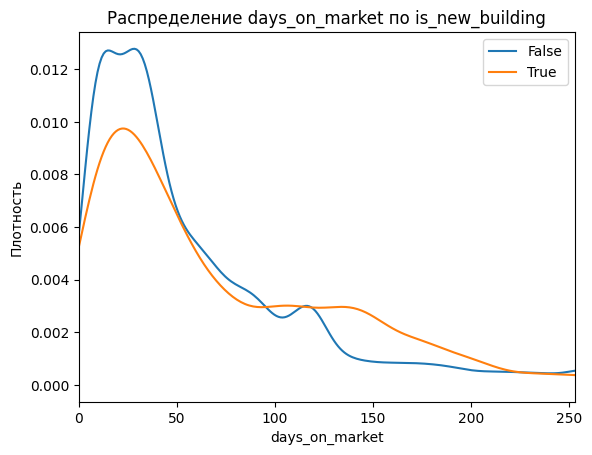

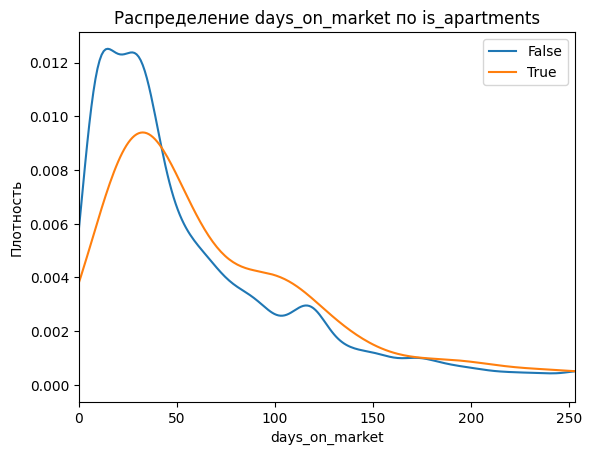

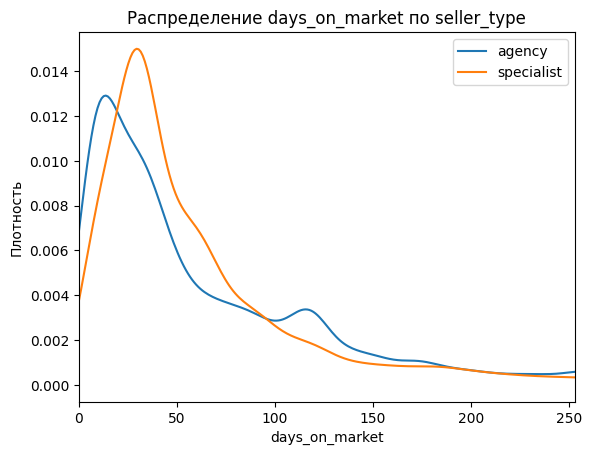

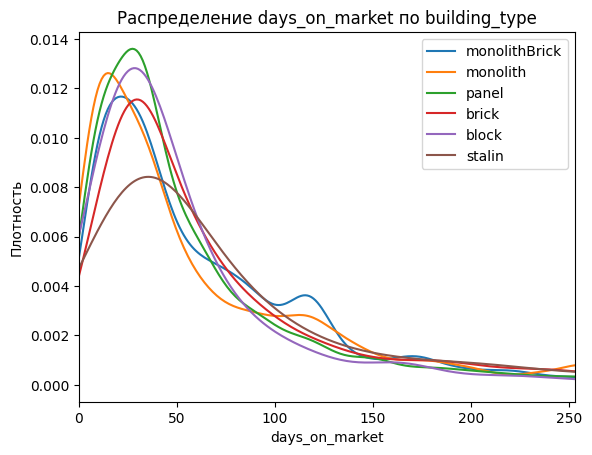

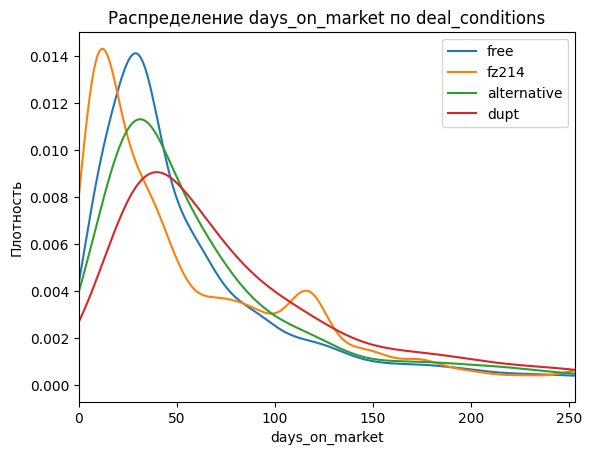

In [15]:
overlay_features = ['is_new_building', 'is_apartments', 'seller_type', 'building_type', 'deal_conditions']
clip = dt['days_on_market'].quantile(0.95)

for col in overlay_features:
    counts = dt[dt[col].ne('unknown')][col].value_counts()
    cats = counts[counts >= 500].index
    plt.figure()
    for val in cats:
        dt.loc[dt[col] == val, 'days_on_market'].plot(kind='kde', label=str(val))
    plt.title(f'Распределение days_on_market по {col}')
    plt.xlabel('days_on_market')
    plt.ylabel('Плотность')
    plt.xlim(0, clip)
    plt.legend()
    plt.show()

Посмотрим, где должна находиться квартира, чтобы ее быстрее можно было продать

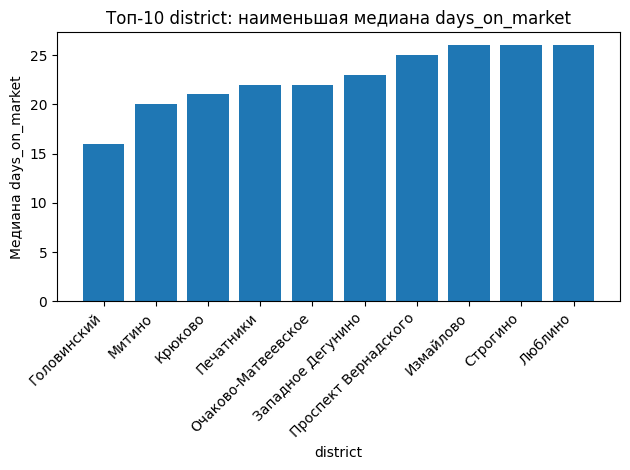

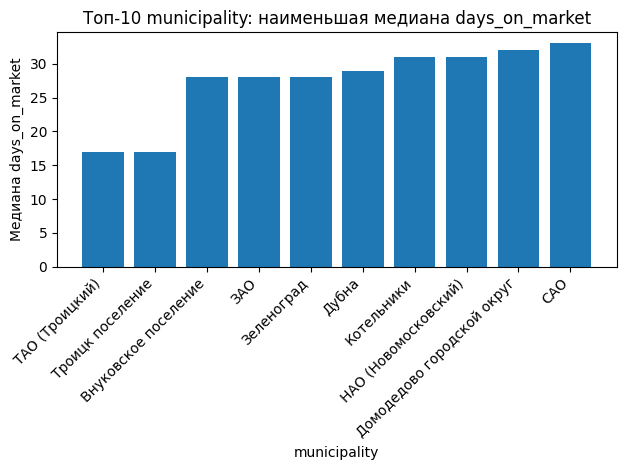

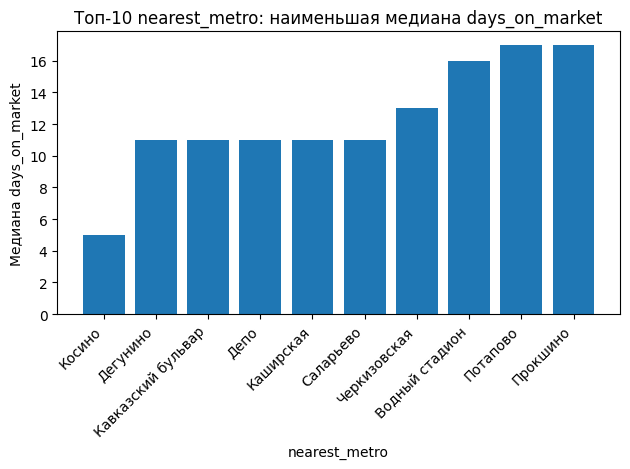

In [16]:
def lowest_median_bar(frame, col, target='days_on_market', top=10, min_count=100):
    sub = frame[frame[col].ne('unknown')]
    stats = sub.groupby(col)[target].agg(['median', 'count'])
    stats = stats[stats['count'] >= min_count].sort_values('median').head(top)
    plt.figure()
    plt.bar(stats.index, stats['median'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Топ-{top} {col}: наименьшая медиана days_on_market')
    plt.xlabel(col)
    plt.ylabel('Медиана days_on_market')
    plt.tight_layout()
    plt.show()

for col in ['district', 'municipality', 'nearest_metro']:
    lowest_median_bar(dt, col)

### Распределение таргета (price_per_m2) по категориальным признакам

In [17]:
def target_by_category(frame, col, target='price_per_m2', min_count=200):
    g = frame.groupby(col)[target]
    table = g.agg(
        n='count',
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        p50='median',
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    return table[table['n'] >= min_count].sort_values('p50').round(1)

cat_features = ['region', 'seller_type', 'seller_user_type', 'room_type', 'rooms', 'is_new_building', 'is_apartments',
                'deal_conditions', 'building_type', 'renovation', 'parking', 'flat_type',
                'has_lift', 'mortgage_allowed', 'nearest_metro_walk',
                'demolished_in_renovation', 'is_penthouse', 'seller_is_owner']

for col in cat_features:
    print(col)
    display(target_by_category(dt, col))

region


,n,p10,p25,p50,p75,p90
region,,,,,,
Московская область,52524,146379.0,175280.9,213603.4,261904.8,312374.5
Москва,79664,285383.9,337400.0,409823.0,522470.2,646281.9


seller_type


,n,p10,p25,p50,p75,p90
seller_type,,,,,,
specialist,44923,159090.9,210872.4,324324.3,441029.4,586206.9
agency,87169,182808.7,235200.0,330241.6,443275.0,574900.0


seller_user_type


...

,n,p10,p25,p50,p75,p90
demolished_in_renovation,,,,,,
False,131951,173015.9,227621.5,328100.0,442156.1,578600.0
True,237,354749.5,393258.4,440678.0,483552.6,524214.5


is_penthouse


,n,p10,p25,p50,p75,p90
is_penthouse,,,,,,
False,132178,173076.9,227790.4,328400.0,442479.8,578489.4


seller_is_owner


,n,p10,p25,p50,p75,p90
seller_is_owner,,,,,,
True,1254,163319.7,207070.7,292469.2,403466.1,520263.3
False,130934,173203.0,228000.0,328806.2,442857.1,578812.6


В таблицах можем увидеть распределение цены за кв. метр по соответствующим квантилям

Посмотрим как различные факторы влияют на цену квартиры за кв. метр

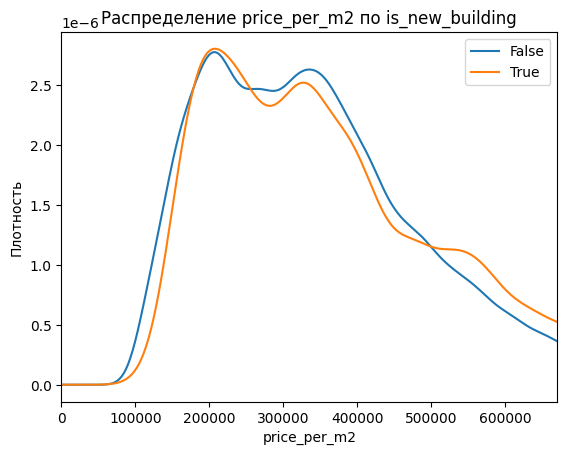

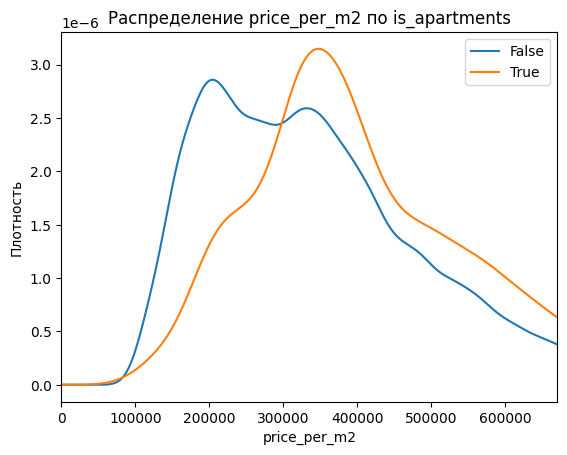

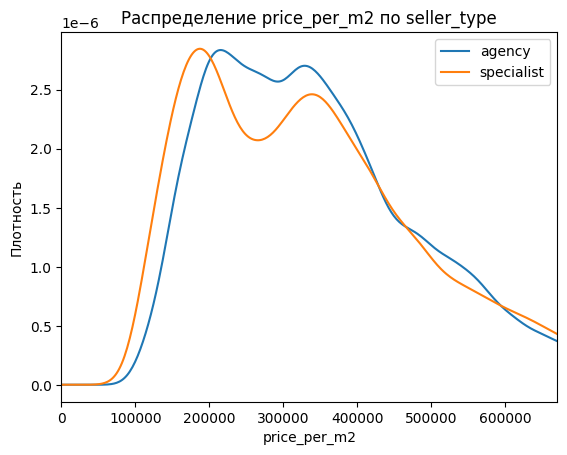

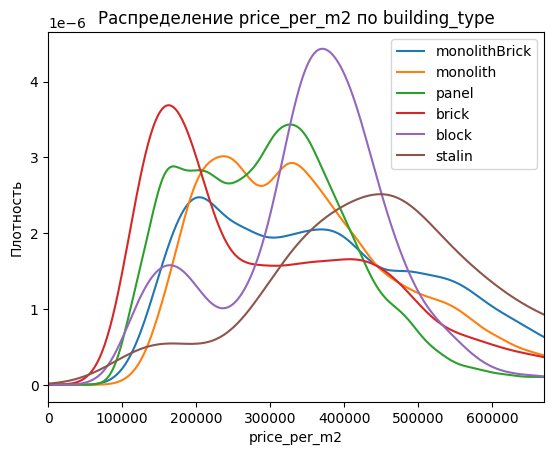

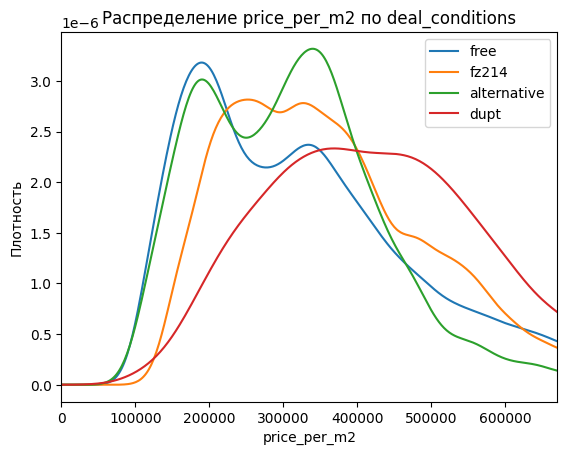

In [18]:
overlay_features = ['is_new_building', 'is_apartments', 'seller_type', 'building_type', 'deal_conditions']
clip = dt['price_per_m2'].quantile(0.95)

for col in overlay_features:
    counts = dt[dt[col].ne('unknown')][col].value_counts()
    cats = counts[counts >= 500].index
    plt.figure()
    for val in cats:
        dt.loc[dt[col] == val, 'price_per_m2'].plot(kind='kde', label=str(val))
    plt.title(f'Распределение price_per_m2 по {col}')
    plt.xlabel('price_per_m2')
    plt.ylabel('Плотность')
    plt.xlim(0, clip)
    plt.legend()
    plt.show()

Посмотрим, где должна находиться квартира, чтобы ее можно было дороже продать

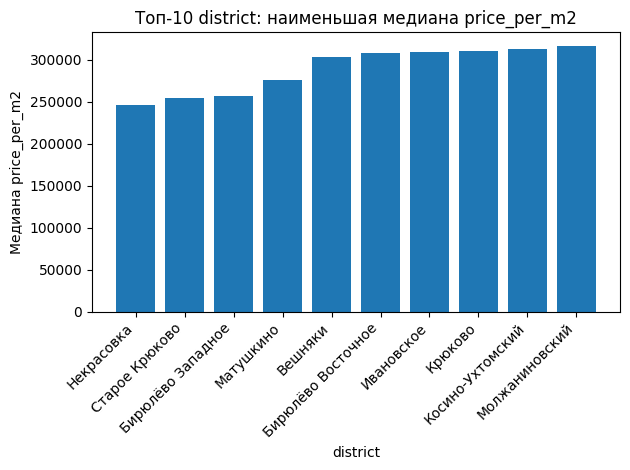

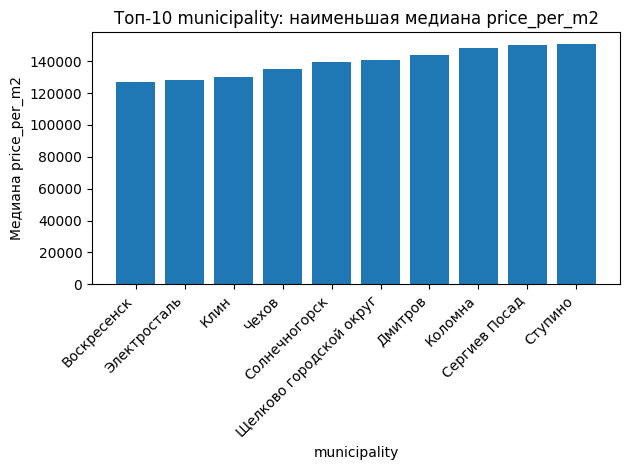

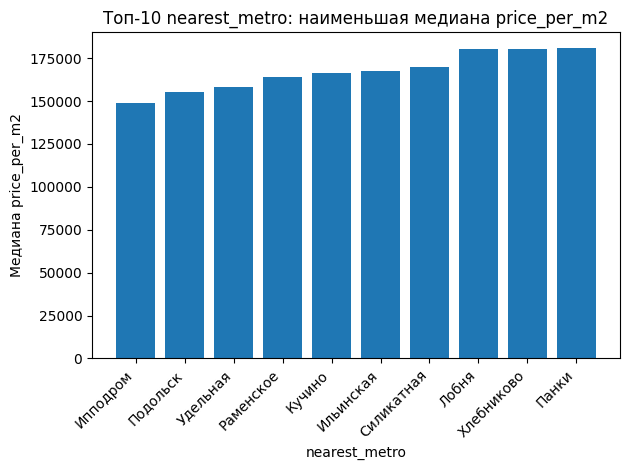

In [19]:
def lowest_median_bar(frame, col, target='price_per_m2', top=10, min_count=100):
    sub = frame[frame[col].ne('unknown')]
    stats = sub.groupby(col)[target].agg(['median', 'count'])
    stats = stats[stats['count'] >= min_count].sort_values('median').head(top)
    plt.figure()
    plt.bar(stats.index, stats['median'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Топ-{top} {col}: наименьшая медиана price_per_m2')
    plt.xlabel(col)
    plt.ylabel('Медиана price_per_m2')
    plt.tight_layout()
    plt.show()

for col in ['district', 'municipality', 'nearest_metro']:
    lowest_median_bar(dt, col)

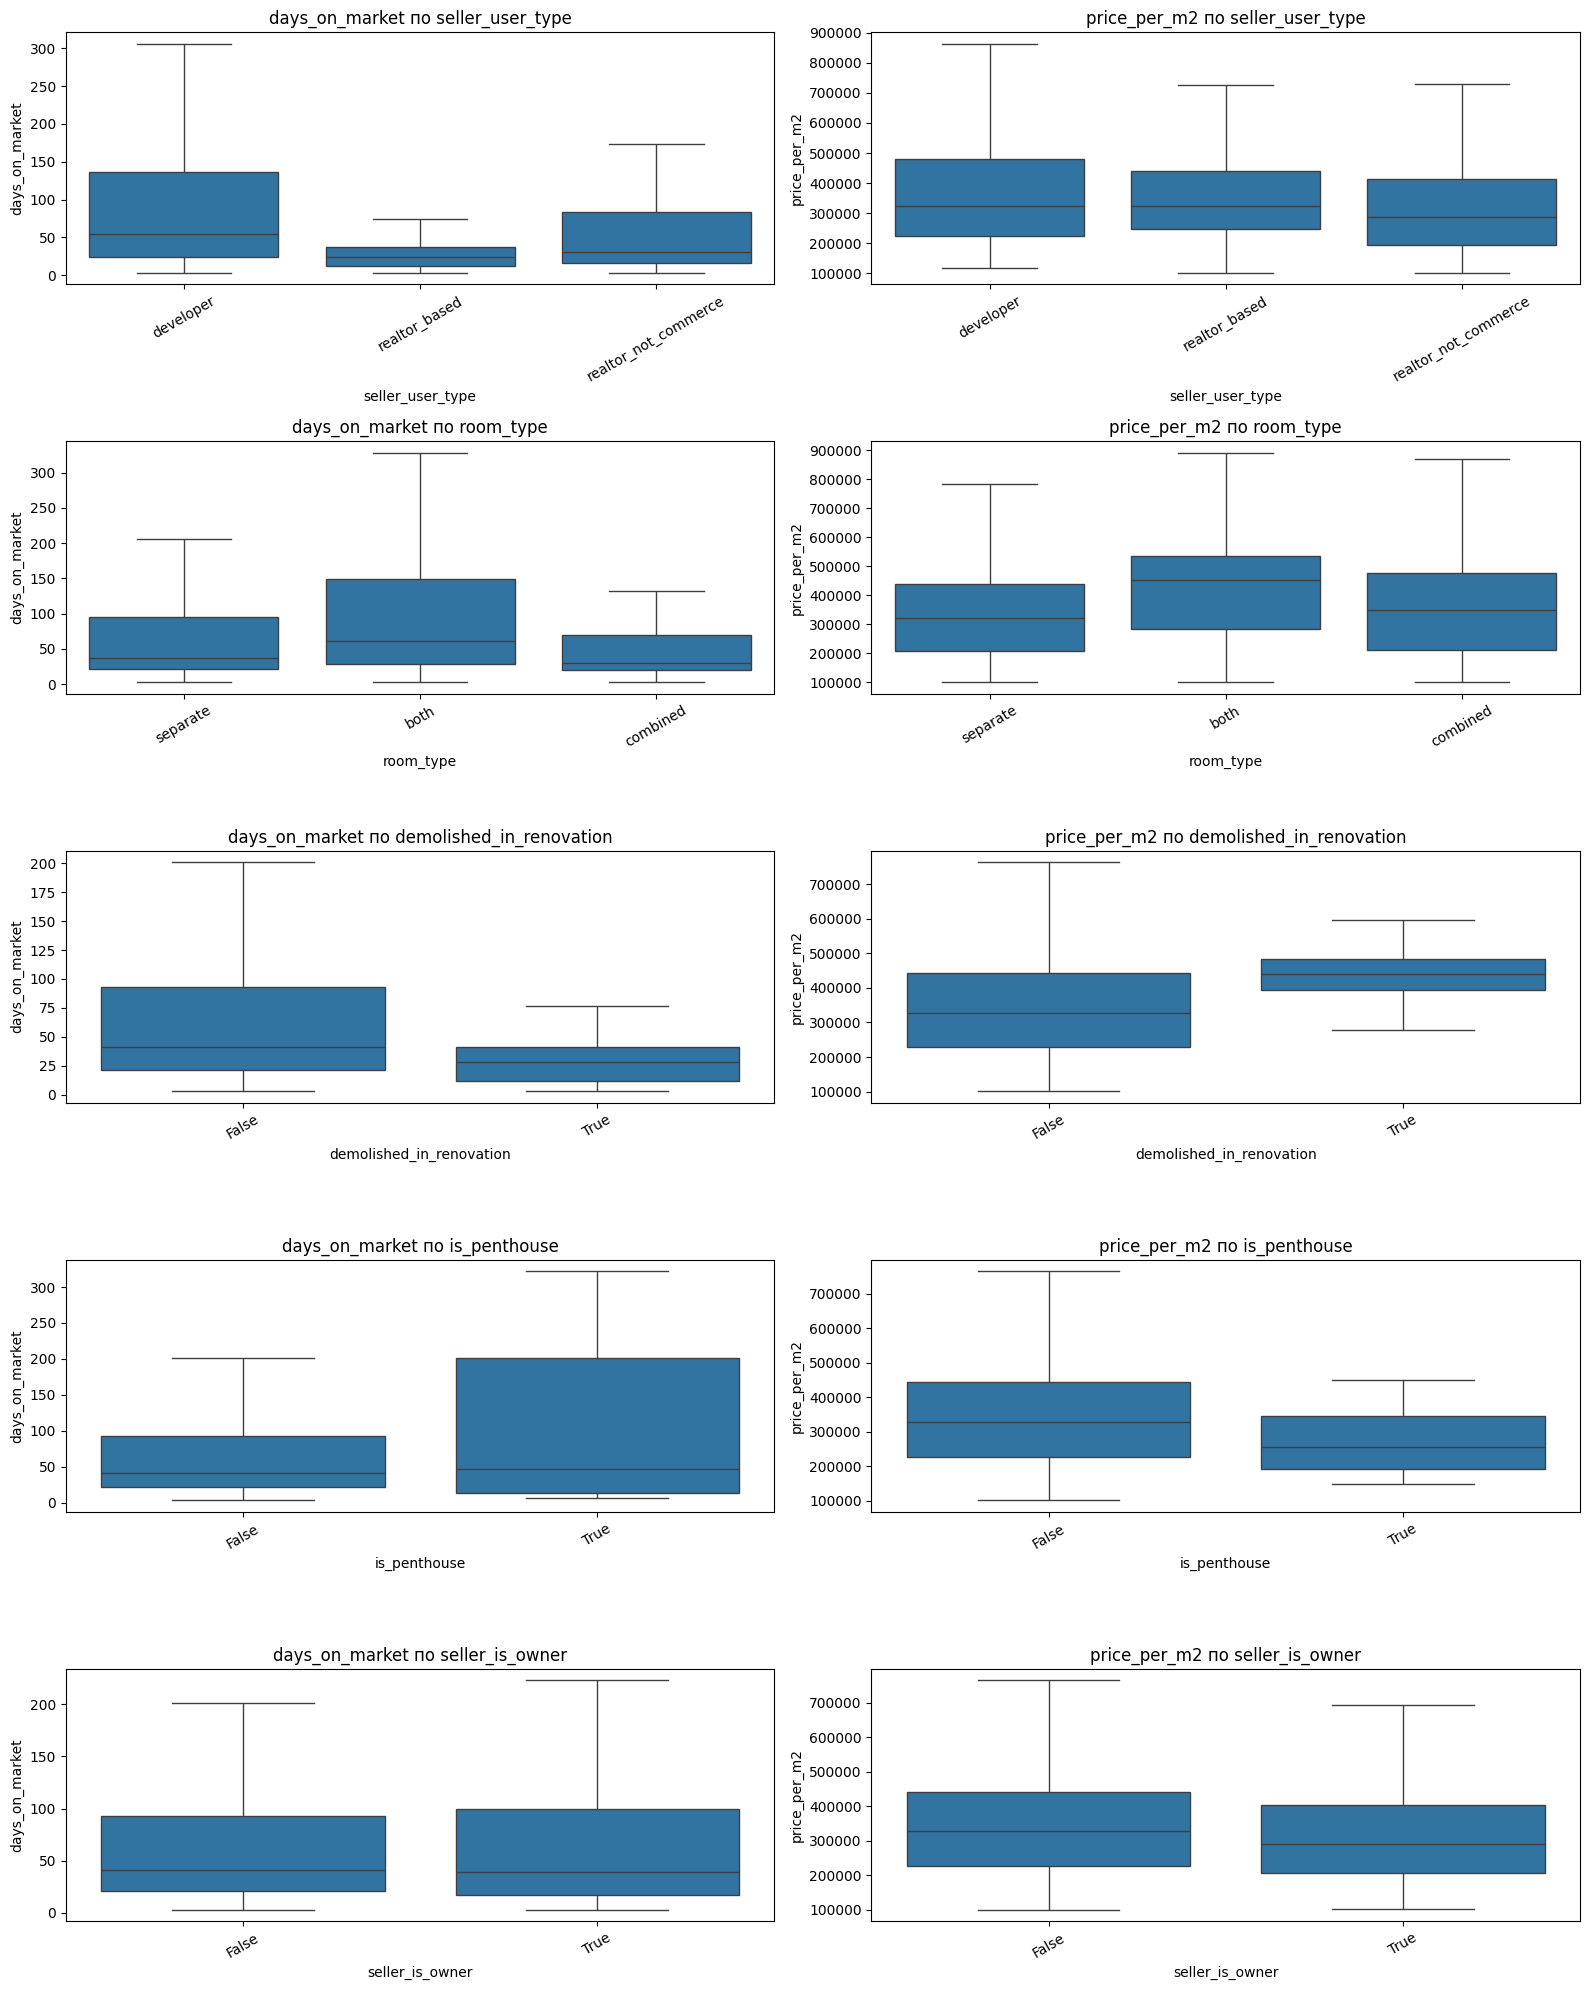

In [20]:
new_cat = ['seller_user_type', 'room_type', 'demolished_in_renovation', 'is_penthouse', 'seller_is_owner']

fig, axes = plt.subplots(len(new_cat), 2, figsize=(16, 4 * len(new_cat)))
for row, col in enumerate(new_cat):
    sub = dt[dt[col].ne('unknown')] if dt[col].dtype == 'str' else dt
    order = sub[col].value_counts().index
    sns.boxplot(data=sub, x=col, y='days_on_market', order=order, ax=axes[row, 0], showfliers=False)
    axes[row, 0].set_title(f'days_on_market по {col}')
    axes[row, 0].tick_params(axis='x', rotation=30)
    sns.boxplot(data=sub, x=col, y='price_per_m2', order=order, ax=axes[row, 1], showfliers=False)
    axes[row, 1].set_title(f'price_per_m2 по {col}')
    axes[row, 1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### Анализ важности признаков

c:\Users\Никита\Study\Master\Data_Science\DA_real_estate\.venv\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable event_closed for analysis 1. Dropping this column
  warnings.warn(


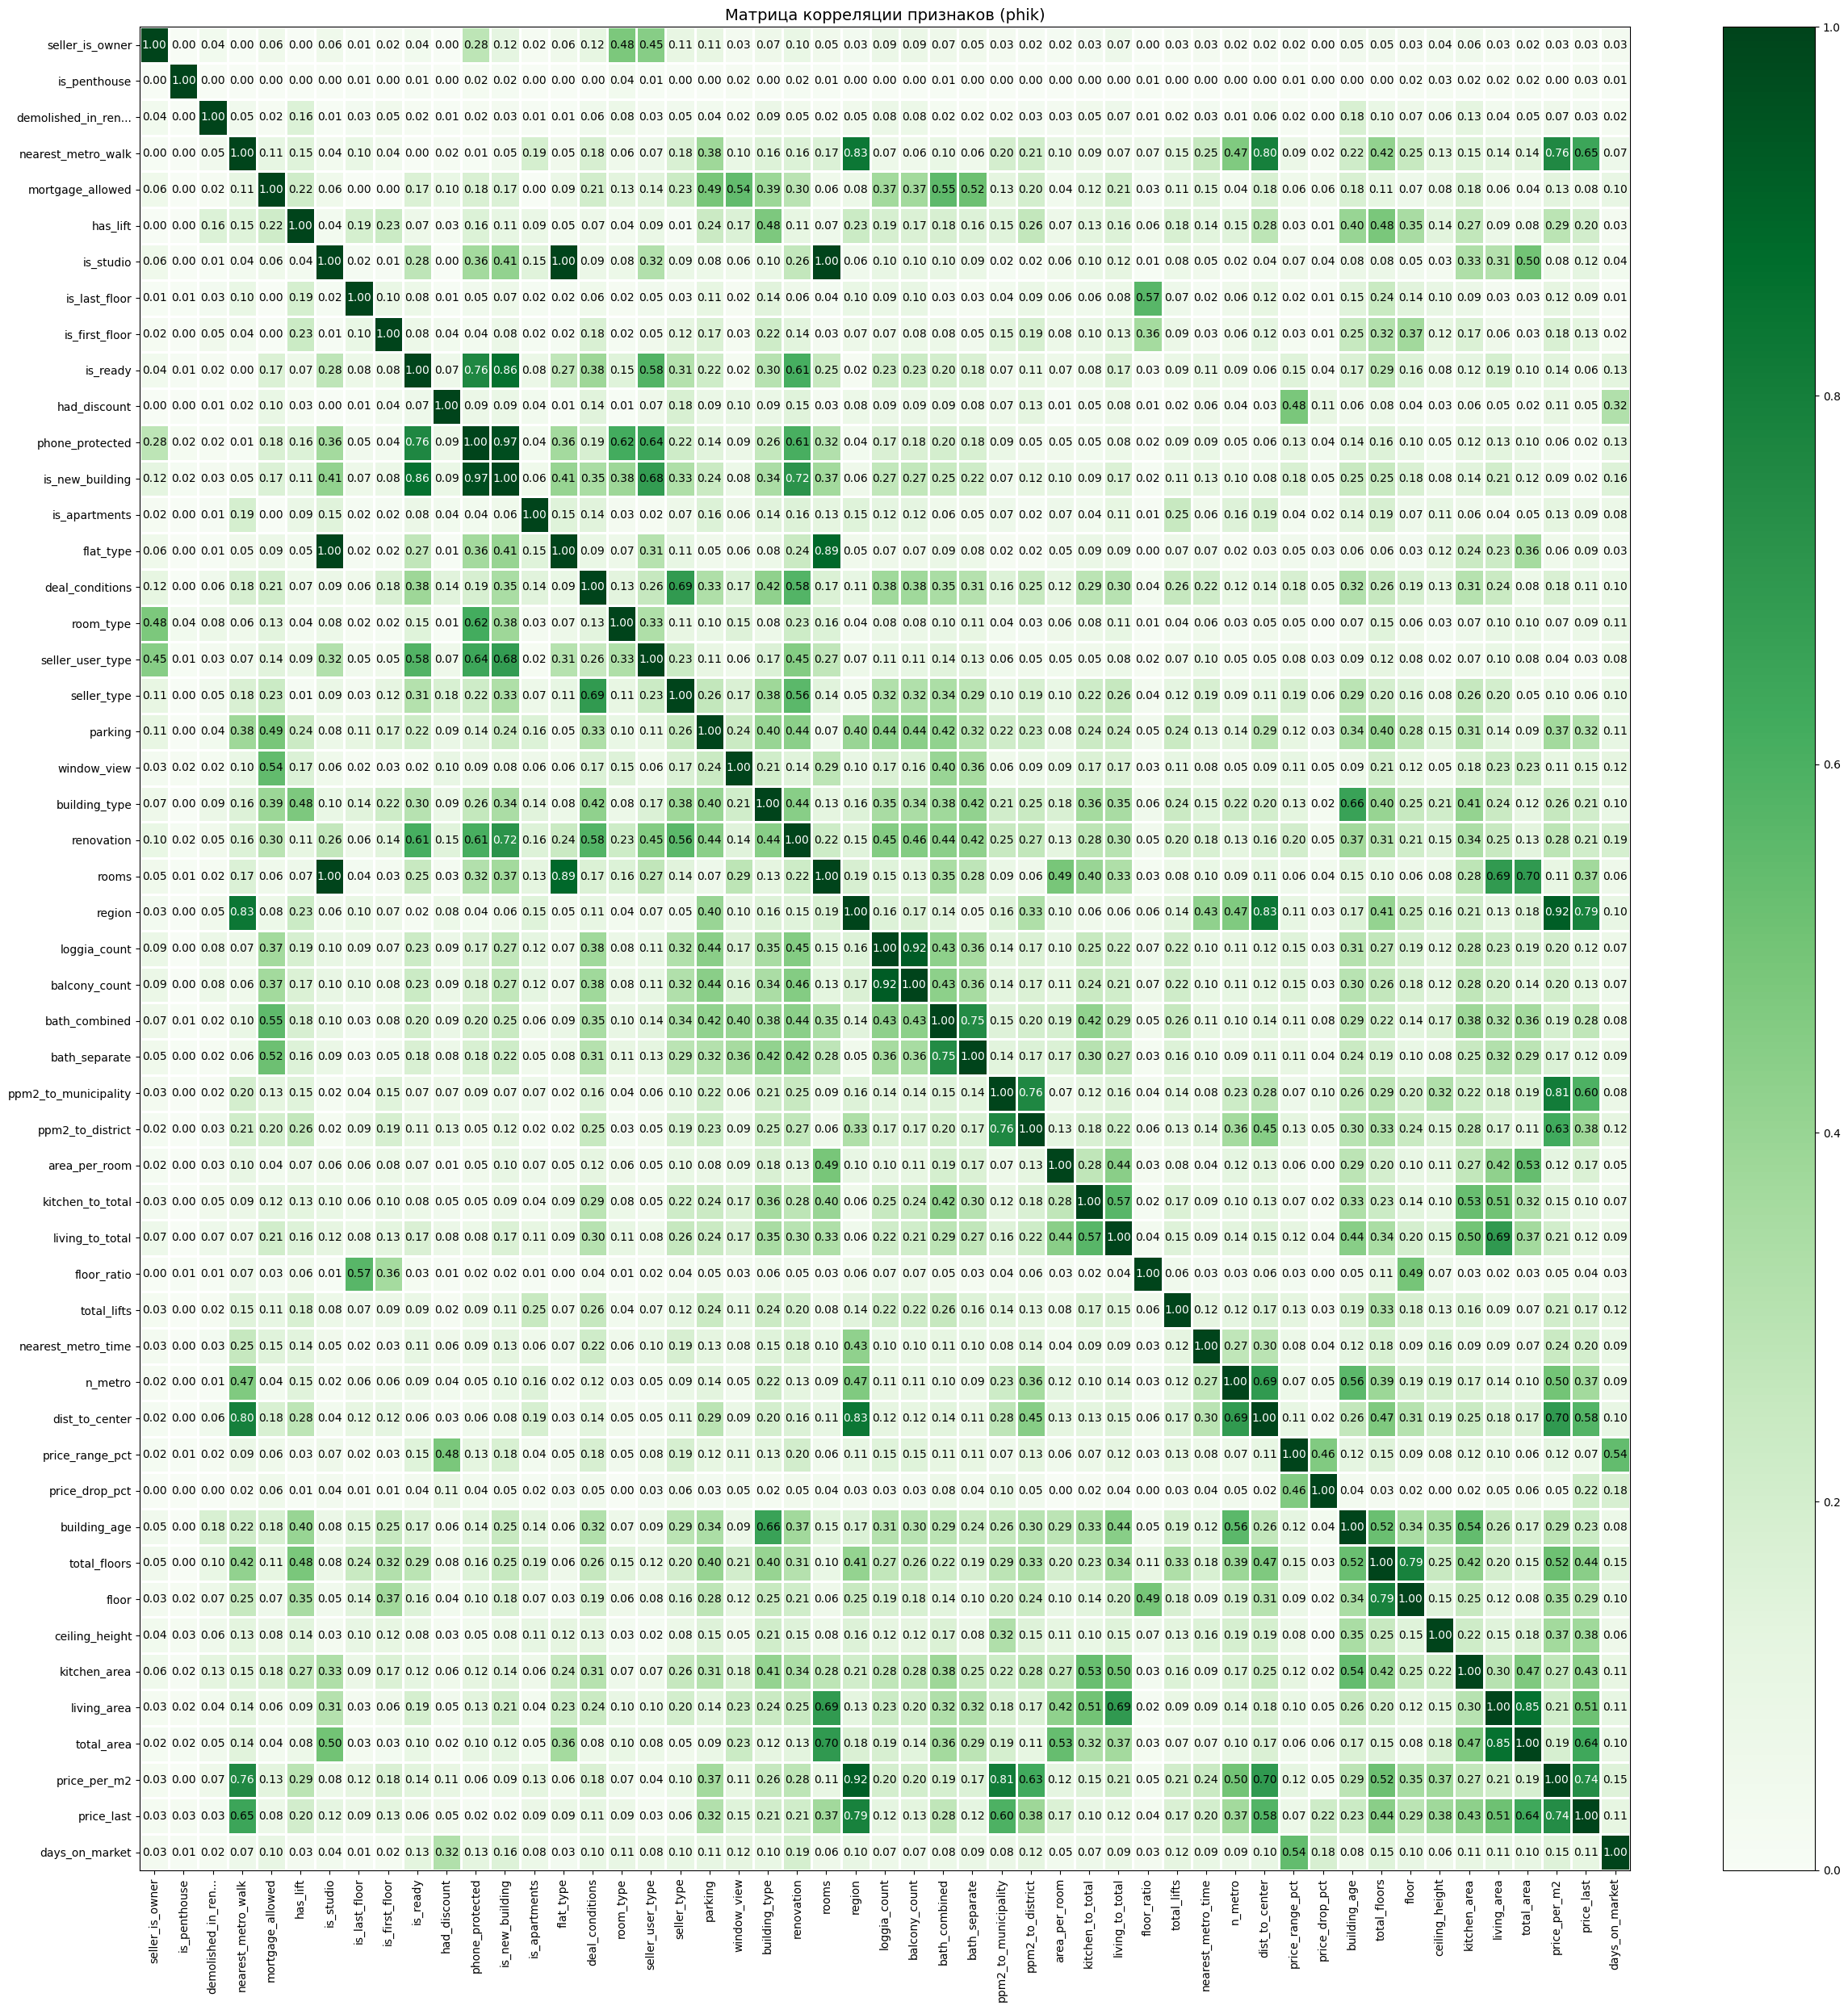

In [21]:
interval_cols = [
    'days_on_market', 'price_last', 'price_per_m2', 'total_area', 'living_area',
    'kitchen_area', 'ceiling_height', 'floor', 'total_floors', 'building_age',
    'price_drop_pct', 'price_range_pct', 'dist_to_center', 'n_metro', 'nearest_metro_time', 'total_lifts',
    'floor_ratio', 'living_to_total', 'kitchen_to_total', 'area_per_room',
    'ppm2_to_district', 'ppm2_to_municipality',
    'bath_separate', 'bath_combined', 'balcony_count', 'loggia_count',
]
phik_cols = interval_cols + [
    'region', 'rooms', 'renovation', 'building_type', 'window_view',
    'parking', 'seller_type', 'seller_user_type', 'room_type', 'deal_conditions', 'flat_type', 'is_apartments', 'is_new_building',
    'phone_protected', 'had_discount', 'is_ready', 'event_closed',
    'is_first_floor', 'is_last_floor', 'is_studio', 'has_lift', 'mortgage_allowed', 'nearest_metro_walk',
    'demolished_in_renovation', 'is_penthouse', 'seller_is_owner',
]

phik_df = dt[phik_cols].copy()
phik_df[interval_cols] = phik_df[interval_cols].astype('float64')
for col in phik_cols:
    if str(phik_df[col].dtype) in ('boolean', 'bool', 'Int64'):
        phik_df[col] = phik_df[col].astype('int64').astype('object')

phik_matrix = phik_df.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1, color_map='Greens',
    title='Матрица корреляции признаков (phik)',
    fontsize_factor=1,
    figsize=(25, 25)
)
plt.tight_layout()
plt.show()

### Бейзлайн и анализ важности признаков

In [22]:
leak_cols = ['days_on_market', 'first_seen', 'event_closed', 'price_points',
             'views_total', 'views_today', 'photos_count', 'had_discount', 'price_drop_pct', 'status']

y = dt['days_on_market'].astype(float)
X = dt.drop(columns=[c for c in leak_cols if c in dt.columns])

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype('category')

X.shape, len(cat_cols)

C:\Users\Nikita\AppData\Local\Temp\ipykernel_11300\3960145859.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


((132188, 59), 13)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=93,
    subsample=1,
    colsample_bytree=1,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train, categorical_feature=cat_cols)

pred = model.predict(X_test)
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
print('R2:', round(r2, 4))
print('MAE (дней):', round(mae, 1))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030950 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5646
[LightGBM] [Info] Number of data points in the train set: 105750, number of used features: 58
[LightGBM] [Info] Start training from score 71.895660
R2: 0.582
MAE (дней): 30.7


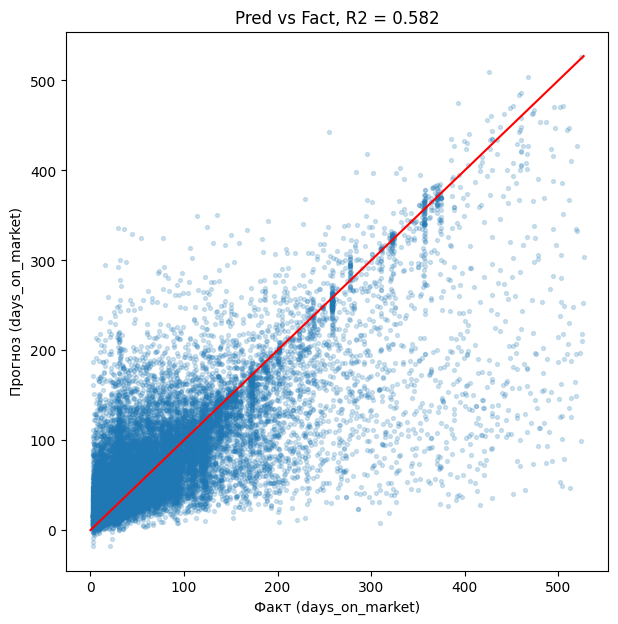

In [24]:
lim = max(y_test.max(), pred.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.2, s=8)
plt.plot([0, lim], [0, lim], color='red')
plt.xlabel('Факт (days_on_market)')
plt.ylabel('Прогноз (days_on_market)')
plt.title(f'Pred vs Fact, R2 = {round(r2, 3)}')
plt.show()

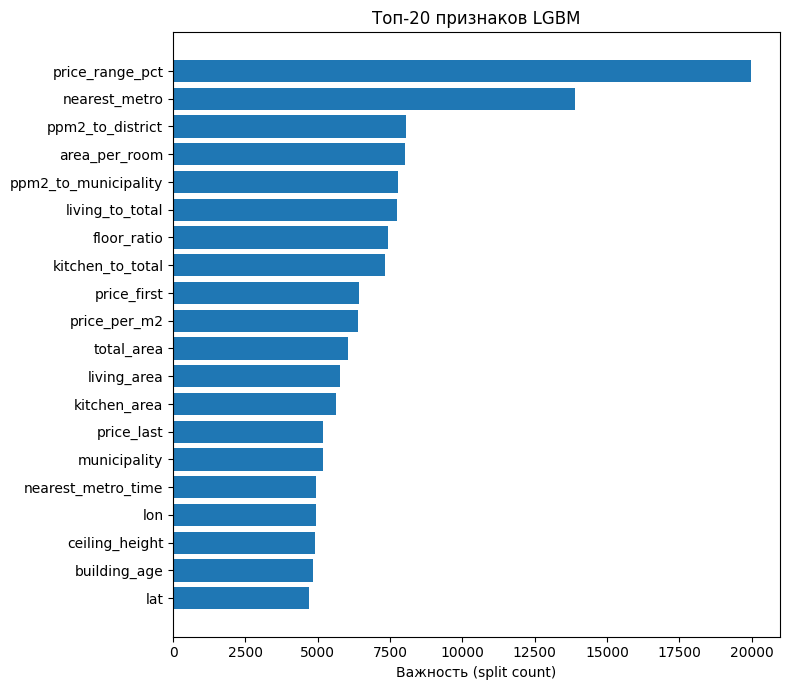

In [25]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(20)

plt.figure(figsize=(8, 7))
plt.barh(importance.index, importance.values)
plt.xlabel('Важность (split count)')
plt.title('Топ-20 признаков LGBM')
plt.tight_layout()
plt.show()

### Финальный экспорт датасета

In [26]:
final = dt.copy()
bool_cols = final.select_dtypes(include='bool').columns
final[bool_cols] = final[bool_cols].astype('int8')
final.to_csv('./notebooks/data/data_final.csv', index=False)
final.shape

(132188, 67)